# Chapter 02 — Parametric Yield Curve Models

## Nelson-Siegel Yield Curve Modeling

This notebook demonstrates how to:

- load market zero rate data
- calibrate the Nelson-Siegel model
- interpret model parameters
- generate smooth yield curves
- compute discount factors
- compute forward rates
- compare market vs fitted curves

The notebook also explains why parametric yield curve models are widely used in:

- front-office trading systems
- risk management
- macroeconomic analysis
- XVA systems

---

## Learning Objectives

After completing this notebook, you should understand:

1. Why bootstrapped curves can become noisy
2. Why traders prefer smooth parametric curves
3. How Nelson-Siegel factors affect curve shape
4. How calibration works
5. How forward rates depend on curve smoothness

---

## FO Quant Perspective

In real trading systems, curve smoothness is critical because:

- forward rates are highly sensitive to interpolation
- unstable curves generate unstable DV01
- noisy curves create poor hedge ratios

Parametric models help stabilize:

- pricing
- risk
- sensitivities
- scenario analysis

In [1]:
import sys
sys.path.append("../python")

# Numerical computing
import numpy as np

# Plotting library
import matplotlib.pyplot as plt

# Local project modules
from market_curve import MarketCurve
from calibration import calibrate_nelson_siegel
from nelson_siegel import NelsonSiegelCurve
from plotting import plot_curve

# Improve chart appearance
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


# Loading Market Curve Data

We now load a simplified USD zero rate curve.

The market data contains:

- maturity
- market zero rate

In real trading systems, these market quotes would come from:

- OIS swaps
- IRS swaps
- treasury bonds
- futures
- FRA instruments

For educational purposes, we use simplified zero rate observations.


In [3]:
curve = MarketCurve(
    "../data/usd_zero_curve_sample.csv"
)

times = curve.times
rates = curve.rates

print("Market maturities:")
print(times)

print("\nMarket zero rates:")
print(rates)

Market maturities:
[ 0.25  0.5   1.    2.    3.    5.    7.   10.   15.   20.   30.  ]

Market zero rates:
[0.02   0.021  0.022  0.024  0.025  0.027  0.0285 0.03   0.032  0.033
 0.034 ]


# Visualizing the Market Curve

Before calibration, we first visualize the raw market curve.

This is important because:

- curve shape impacts pricing
- curve smoothness impacts forwards
- traders monitor curve steepness continuously

Typical curve shapes include:

- upward sloping
- inverted
- humped
- flat

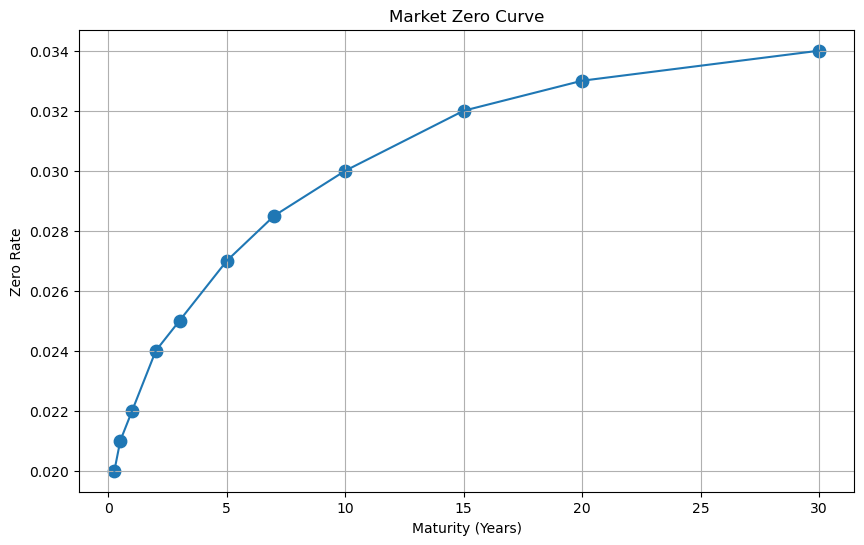

In [4]:
plt.figure()

plt.scatter(
    times,
    rates,
    s=80
)

plt.plot(
    times,
    rates
)

plt.title("Market Zero Curve")
plt.xlabel("Maturity (Years)")
plt.ylabel("Zero Rate")

plt.grid()

plt.show()

# Nelson-Siegel Model

The Nelson-Siegel model expresses the yield curve as:

$$
y(t)
= \beta_0
+
\beta_1
\left(
\frac{1-e^{-t/\tau}}{t/\tau}
\right)
+
\beta_2
\left(
\frac{1-e^{-t/\tau}}{t/\tau}
- e^{-t/\tau}
\right)
$$

---

## Parameter Interpretation

### $$\beta_0$$

Long-term level factor.

Controls the asymptotic level of the curve.

---

### $$\beta_1$$

Slope factor.

Controls steepness of the short end.

---

### $$\beta_2$$

Curvature factor.

Controls hump shape in medium maturities.

---

### $$\tau$$

Decay parameter.

Controls where the hump appears.

# Model Calibration

We now calibrate the model parameters.

Calibration means:

$$
\text{Find parameters minimizing fitting error}
$$

The optimization minimizes:

$$
\sum_i
(y_{market} - y_{model})^2
$$

This is a nonlinear optimization problem.

In production systems, calibration quality is extremely important because:

- poor calibration creates unstable risk
- noisy parameters produce unstable forwards
- pricing consistency depends on curve stability

In [5]:
params = calibrate_nelson_siegel(
    times,
    rates
)

print("Calibrated Parameters:")
print()

print(f"beta0 = {params[0]:.6f}")
print(f"beta1 = {params[1]:.6f}")
print(f"beta2 = {params[2]:.6f}")
print(f"tau   = {params[3]:.6f}")

Calibrated Parameters:

beta0 = 0.035907
beta1 = -0.015980
beta2 = -0.000000
tau   = 3.762262


# Interpreting the Parameters

We now interpret the calibrated factors.

---

## beta0 — Long-Term Level

Higher beta0 means:

- higher long-end rates
- higher discounting
- lower bond prices

---

## beta1 — Slope

Negative beta1 usually indicates:

- upward sloping curve
- normal economic environment

Positive beta1 may indicate:

- inverted yield curve
- restrictive monetary policy

---

## beta2 — Curvature

Controls medium maturity hump.

Strong curvature affects:

- belly trades
- butterfly strategies
- forward volatility

---

## tau — Hump Location

Controls where curvature peaks.

In [6]:
model = NelsonSiegelCurve(*params)

print("Nelson-Siegel curve constructed successfully.")

Nelson-Siegel curve constructed successfully.


# Market vs Fitted Curve

We now compare:

- market observations
- fitted Nelson-Siegel curve

A good fit should:

- remain smooth
- avoid oscillations
- preserve market shape

Unlike spline interpolation, parametric models intentionally sacrifice perfect fit quality in exchange for:

- stability
- smoothness
- interpretability


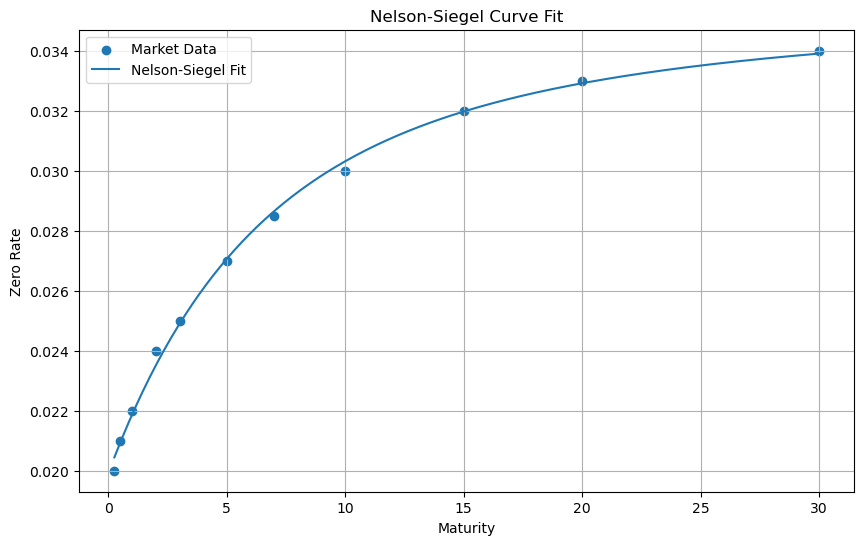

In [7]:
plot_curve(
    times,
    rates,
    model
)


# Zero Rate Extraction

We now evaluate the fitted curve at several maturities.

These zero rates are used for:

- discounting
- pricing swaps
- pricing bonds
- XVA exposure calculations

In [8]:
test_maturities = [1, 2, 5, 10, 20, 30]

for t in test_maturities:

    r = model.zero_rate(t)

    print(
        f"Maturity = {t:2d}Y | "
        f"Zero Rate = {r:.4%}"
    )

Maturity =  1Y | Zero Rate = 2.1874%
Maturity =  2Y | Zero Rate = 2.3512%
Maturity =  5Y | Zero Rate = 2.7066%
Maturity = 10Y | Zero Rate = 3.0316%
Maturity = 20Y | Zero Rate = 3.2916%
Maturity = 30Y | Zero Rate = 3.3904%


# Discount Factors

Discount factors are computed using:

$$
DF(t) = e^{-r(t)t}
$$

Discount factors represent:

> Present value of receiving 1 unit of currency at time t.

Discount factors are fundamental in all interest rate pricing systems.

In [9]:
for t in test_maturities:

    df = model.discount_factor(t)

    print(
        f"Maturity = {t:2d}Y | "
        f"Discount Factor = {df:.6f}"
    )

Maturity =  1Y | Discount Factor = 0.978363
Maturity =  2Y | Discount Factor = 0.954065
Maturity =  5Y | Discount Factor = 0.873427
Maturity = 10Y | Discount Factor = 0.738479
Maturity = 20Y | Discount Factor = 0.517723
Maturity = 30Y | Discount Factor = 0.361638


# Forward Rates

Forward rates are implied future interest rates.

They are computed from discount factors:

$$
F(t_1,t_2)
= [\frac{DF(t_1)}{DF(t_2)} - 1] \cdot \frac{1}{t_2 - t_1}
$$

Forward rates are extremely important in:

- swap pricing
- FRA pricing
- LIBOR market models
- interest rate derivatives

---

## Important FO Insight

Forward rates are highly sensitive to:

- interpolation
- curve smoothness
- calibration stability

This is one major reason why trading desks often prefer parametric curves.

In [10]:
times_dense = np.linspace(0.25, 29.5, 150)

fwds = [
    model.forward_rate(t, t + 0.25)
    for t in times_dense
]

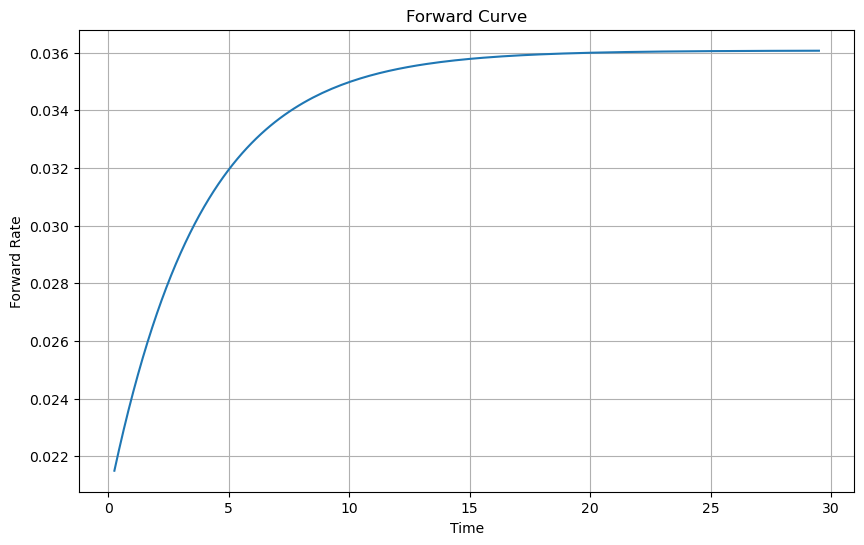

In [11]:
plt.figure()

plt.plot(
    times_dense,
    fwds
)

plt.title("Forward Curve")
plt.xlabel("Time")
plt.ylabel("Forward Rate")

plt.grid()

plt.show()


# Front-Office Trading Interpretation

The shape of the forward curve contains important macro information.

---

## Upward Sloping Forward Curve

May indicate:

- expected economic growth
- inflation expectations
- higher future rates

---

## Downward Forward Curve

May indicate:

- expected rate cuts
- recession concerns
- monetary tightening cycle ending

---

## Curvature Effects

Humps in the forward curve are important for:

- butterfly trades
- curve RV strategies
- swap spread trading

# Stress Testing Nelson-Siegel Factors

One major advantage of parametric models is intuitive scenario analysis.

We can shock parameters directly.

Examples:

| Shock | Interpretation |
|---|---|
| Increase beta0 | Parallel shift |
| Increase beta1 | Curve steepening |
| Increase beta2 | Belly hump |

This is heavily used in:

- VaR systems
- macro trading
- stress testing

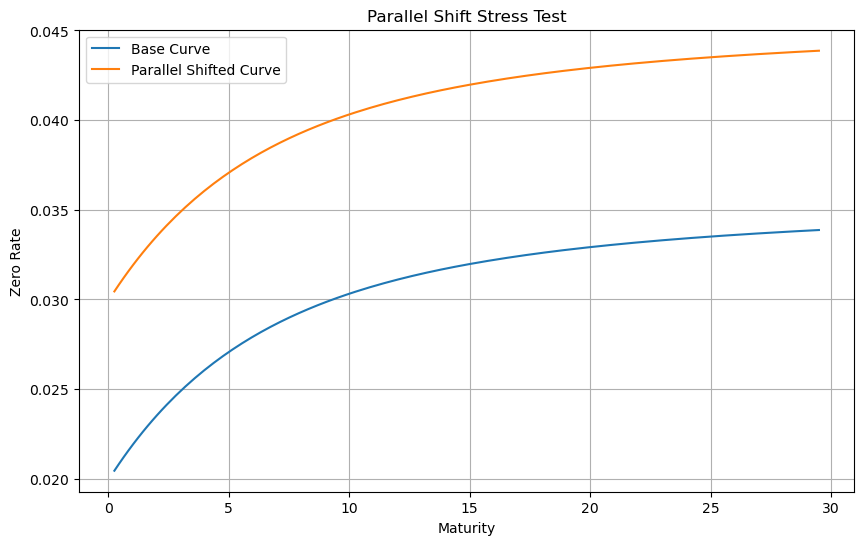

In [13]:
stressed_model = NelsonSiegelCurve(
    params[0] + 0.01,
    params[1],
    params[2],
    params[3]
)

base_rates = [
    model.zero_rate(t)
    for t in times_dense
]

stressed_rates = [
    stressed_model.zero_rate(t)
    for t in times_dense
]

plt.figure()

plt.plot(
    times_dense,
    base_rates,
    label="Base Curve"
)

plt.plot(
    times_dense,
    stressed_rates,
    label="Parallel Shifted Curve"
)

plt.title("Parallel Shift Stress Test")

plt.xlabel("Maturity")
plt.ylabel("Zero Rate")

plt.legend()

plt.grid()

plt.show()

# Svensson Model 

The Svensson model extends the Nelson-Siegel framework
by introducing an additional curvature factor.

This improves flexibility for fitting more complex
yield curve shapes.

The Svensson model is written as:

$$
y(t)
=
\beta_0
+
\beta_1 f_1(t)
+
\beta_2 f_2(t)
+
\beta_3 f_3(t)
$$

where:

$$
f_1(t)
=
\frac{1-e^{-t/\tau_1}}{t/\tau_1}
$$

$$
f_2(t)
=
\frac{1-e^{-t/\tau_1}}{t/\tau_1}
-
e^{-t/\tau_1}
$$

$$
f_3(t)
=
\frac{1-e^{-t/\tau_2}}{t/\tau_2}
-
e^{-t/\tau_2}
$$

---

## Why Svensson Matters

Nelson-Siegel is sometimes too restrictive because it
only allows one curvature hump.

Svensson introduces a second hump component.

This is useful for modeling:

- long-end curvature
- sovereign bond curves
- central bank term structures
- complex swap curves

---

## FO Quant Perspective

Svensson models are widely used in:

- central bank curve construction
- sovereign debt analysis
- macroeconomic modeling
- stress testing

Compared with Nelson-Siegel:

| Model | Flexibility | Stability |
|---|---|---|
| Nelson-Siegel | Medium | High |
| Svensson | Higher | Slightly lower |

---

## Practical Insight

More flexibility is not always better.

Excessive flexibility may lead to:

- overfitting
- unstable forwards
- noisy sensitivities

FO desks often balance:

- fit quality
- smoothness
- risk stability


# Svensson vs Nelson-Siegel Comparison

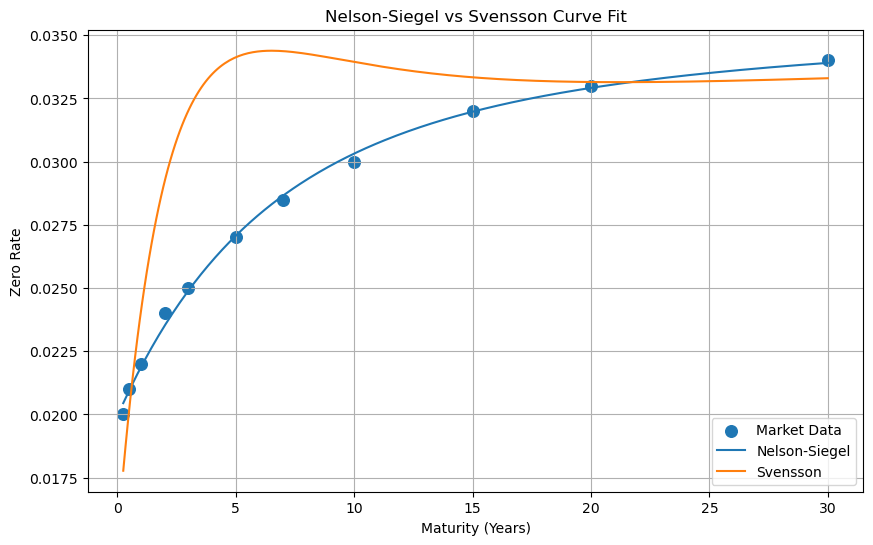

In [15]:

from svensson import SvenssonCurve

# ------------------------------------------------------------
# Example Svensson Parameters
#
# These are manually chosen illustrative parameters.
# In production systems, Svensson parameters are calibrated
# using nonlinear optimization similarly to Nelson-Siegel.
# ------------------------------------------------------------

svensson_model = SvenssonCurve(
    beta0=0.035,
    beta1=-0.020,
    beta2=0.030,
    beta3=-0.010,
    tau1=2.0,
    tau2=8.0
)

# ------------------------------------------------------------
# Generate dense maturity grid
# ------------------------------------------------------------

times_dense = np.linspace(0.25, 30, 300)

# ------------------------------------------------------------
# Compute Nelson-Siegel fitted curve
# ------------------------------------------------------------

ns_rates = [
    model.zero_rate(t)
    for t in times_dense
]

# ------------------------------------------------------------
# Compute Svensson fitted curve
# ------------------------------------------------------------

sv_rates = [
    svensson_model.zero_rate(t)
    for t in times_dense
]

# ------------------------------------------------------------
# Plot comparison
# ------------------------------------------------------------

plt.figure()

# Market observations
plt.scatter(
    times,
    rates,
    s=70,
    label="Market Data"
)

# Nelson-Siegel fit
plt.plot(
    times_dense,
    ns_rates,
    label="Nelson-Siegel"
)

# Svensson fit
plt.plot(
    times_dense,
    sv_rates,
    label="Svensson"
)

plt.title("Nelson-Siegel vs Svensson Curve Fit")

plt.xlabel("Maturity (Years)")
plt.ylabel("Zero Rate")

plt.legend()

plt.grid()

plt.show()

# Summary

In this notebook we implemented:

- Nelson-Siegel curve modeling
- nonlinear parameter calibration
- discount factor extraction
- forward rate generation
- stress testing
- curve visualization

---

## Key Takeaways

### Bootstrapped Curves

Pros:
- exact market fit

Cons:
- noisy forwards
- unstable sensitivities

---

### Parametric Curves

Pros:
- smooth
- stable
- interpretable

Cons:
- imperfect fit

---

## FO Quant Relevance

This topic is highly relevant for:

- rates trading
- swaption desks
- XVA systems
- risk management
- macro strategy

Parametric term structure models are foundational for more advanced models such as:

- Hull-White
- HJM
- LMM
- affine term structure models